# Ajout des bibliothèques nécessaires

In [4]:
#importation des données
import os
import glob
import random

# Manipulation des données
import pandas as pd
import numpy as np

# Outils de Machine Learning (ici je vais utiliser Scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
print("Toutes les bibliothèques sont chargées avec succès !")

Toutes les bibliothèques sont chargées avec succès !


## Segmentation des fichiers en paquets de 5 phrases

In [5]:
def segmenter_en_paquets(texte, taille_paquet=5):
    phrases = texte.splitlines()
    phrases = [p.strip() for p in phrases if p.strip()]

    paquets = []
    for i in range(0, len(phrases), taille_paquet):
        paquet = " ".join(phrases[i:i+taille_paquet])
        paquets.append(paquet)
    return paquets

chemin_dossier = "Z_vs_N"

liste_fichiers = sorted(glob.glob(os.path.join(chemin_dossier, "*.txt")))
print(f"Trouvé {len(liste_fichiers)} fichiers.")


random.seed(1)
random.shuffle(liste_fichiers)
liste_train = liste_fichiers[:40]
liste_test = liste_fichiers[40:]

print(f"Fichiers train : {len(liste_train)}")
print(f"Fichiers test  : {len(liste_test)}")


def construire_dataframe(liste_fichiers):

    donnees = []

    for chemin_fichier in liste_fichiers:
        nom_fichier = os.path.basename(chemin_fichier)
        if nom_fichier.endswith("clean.txt"):
            label = "Zola"
        else:
            label = "naturaliste"
        with open(chemin_fichier, "r", encoding="utf-8") as f:
            texte = f.read()
        blocs = segmenter_en_paquets(texte)
        for bloc in blocs:
            donnees.append({
                "texte": bloc,
                "label": label,
                "source": nom_fichier
            })
    return pd.DataFrame(donnees)


df_train = construire_dataframe(liste_train)
df_test = construire_dataframe(liste_test)

print("-"*30)
print("TRAIN")
print(df_train["label"].value_counts())

print("-"*30)
print("TEST")
print(df_test["label"].value_counts())

Trouvé 49 fichiers.
Fichiers train : 40
Fichiers test  : 9
------------------------------
TRAIN
label
Zola           22094
naturaliste    15301
Name: count, dtype: int64
------------------------------
TEST
label
Zola           5711
naturaliste    3037
Name: count, dtype: int64


In [6]:
print("Segment de phrase dans le train:")
print(len(df_train))

sources_par_label = (
    df_train.groupby("label")["source"]
      .apply(lambda x: x.dropna().unique().tolist())
)

print("-" * 30)
print("Sources par label :")

for label, sources in sources_par_label.items():
    print(f"\n{label} :")
    for source in sources:
        print(f"  - {source}")
        
print("\n\n\nSegment de phrase dans le test:")
print(len(df_test))
        
sources_par_label = (
    df_test.groupby("label")["source"]
      .apply(lambda x: x.dropna().unique().tolist())
)

print("-" * 30)
print("Sources par label :")

for label, sources in sources_par_label.items():
    print(f"\n{label} :")
    for source in sources:
        print(f"  - {source}")

Segment de phrase dans le train:
37395
------------------------------
Sources par label :

Zola :
  - 1873_3_Le_ventre_de_Paris._clean.txt
  - 1888_16_Le_reve._clean.txt
  - 1882_10_Pot-bouille._clean.txt
  - 1876_6_Son_Excellence_Eugene_Rougon._clean.txt
  - 1887_15_La_terre._clean.txt
  - 1884_12_La_joie_de_vivre._clean.txt
  - 1893_20_Le_docteur_Pascal._clean.txt
  - 1885_13_Germinal._clean.txt
  - 1883_11_Au_Bonheur_des_dames._clean.txt
  - 1874_4_La_conquete_de_Plassans._clean.txt
  - 1892_19_La_debacle._clean.txt
  - 1891_18_L_argent._clean.txt
  - 1871_1_La_fortune_des_Rougon._clean.txt
  - 1871_2_La_curee._clean.txt
  - 1877_7_L_assommoir._clean.txt
  - 1886_14_L_oeuvre._clean.txt

naturaliste :
  - malheur d'Henriette Gérard.txt
  - Amis de la nature.txt
  - En route.txt
  - rois_en_exil.txt
  - le_Nabab.txt
  - Germinie Lacerteux.txt
  - L'education_sentimentale.txt
  - Confessions de Sylvius.txt
  - soutien_de_famille.txt
  - Paule Méré.txt
  - Mont Oriol.txt
  - Barbier de 

In [7]:
df_train.head()


,texte,label,source
0,"Au milieu du grand silence, et dans le désert ...",Zola,1873_3_Le_ventre_de_Paris._clean.txt
1,"Il marchait, dormant à demi, dodelinant des or...",Zola,1873_3_Le_ventre_de_Paris._clean.txt
2,"cria un des hommes, qui s’était mis à genoux s...",Zola,1873_3_Le_ventre_de_Paris._clean.txt
3,Eh! l’homme! dit-elle doucement. Mais les char...,Zola,1873_3_Le_ventre_de_Paris._clean.txt
4,"Il regardait Mme François d’un air effaré, san...",Zola,1873_3_Le_ventre_de_Paris._clean.txt


In [8]:
df_test.head()

,texte,label,source
0,I – Un article ?… Tu me demandes s’il y a un a...,naturaliste,Charles Demailly.txt
1,"– Après, après ? tu poses ta femme : une coméd...",naturaliste,Charles Demailly.txt
2,L’autre était un jeune homme de trente-quatre ...,naturaliste,Charles Demailly.txt
3,"Le second, tout entier à faire des appels au m...",naturaliste,Charles Demailly.txt
4,"Ces cinq hommes, qui avaient l’oreille à la bo...",naturaliste,Charles Demailly.txt


# Préparation des données pour le machine learning

In [11]:
# Séparation des textes et des labels
X_train = df_train["texte"]
y_train = df_train["label"]

X_test = df_test["texte"]
y_test = df_test["label"]


# ============================================================
# TF-IDF COMMUN AUX TROIS MODÈLES
# ============================================================

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9
)

# Le vocabulaire et les poids IDF sont appris uniquement sur le train
vectorizer.fit(pd.concat([X_train,X_test]))
X_train_tfidf = vectorizer.transform(X_train)

# Le test est transformé avec exactement le même vocabulaire
X_test_tfidf = vectorizer.transform(X_test)

print("Dimensions du train :", X_train_tfidf.shape)
print("Dimensions du test  :", X_test_tfidf.shape)


Dimensions du train : (37395, 10000)
Dimensions du test  : (8748, 10000)


## 1.  Multinomial Naive Bayes

              precision    recall  f1-score   support

        Zola       0.95      0.94      0.94      5711
 naturaliste       0.89      0.90      0.89      3037

    accuracy                           0.93      8748
   macro avg       0.92      0.92      0.92      8748
weighted avg       0.93      0.93      0.93      8748

[[5378  333]
 [ 308 2729]]


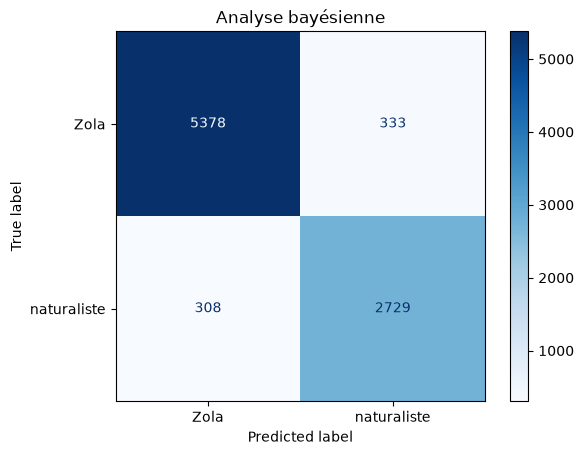

In [12]:
modele_bayes = MultinomialNB(alpha=1.0)

modele_bayes.fit(X_train_tfidf, y_train)


predictions = modele_bayes.predict(X_test_tfidf)

print(classification_report(y_test, predictions))

cm_bayesien = confusion_matrix(y_test, predictions)
print(cm_bayesien)

ConfusionMatrixDisplay(
    confusion_matrix=cm_bayesien,
    display_labels=modele_bayes.classes_
).plot(cmap="Blues")

plt.title("Analyse bayésienne")
plt.show()

In [13]:
vectorizer = vectorizer
classifieur = modele_bayes

mots = vectorizer.get_feature_names_out()
classes = classifieur.classes_

print("Ordre des classes :", classes)

print("Ordre des classes :", classes)

# Différence des log-probabilités entre les deux classes
score_discriminant = (
    classifieur.feature_log_prob_[0]
    - classifieur.feature_log_prob_[1]
)

resultats_mots = pd.DataFrame({
    "mot": mots,
    f"score_{classes[0]}": score_discriminant
})

# Mots les plus caractéristiques de la première classe
mots_classe_0 = resultats_mots.sort_values(
    f"score_{classes[0]}",
    ascending=False
).head(30)

# Mots les plus caractéristiques de la deuxième classe
mots_classe_1 = resultats_mots.sort_values(
    f"score_{classes[0]}",
    ascending=True
).head(30)

print(f"\nMots les plus caractéristiques de {classes[0]} :")
for _, ligne in mots_classe_0.iterrows():
    print(f"{ligne['mot']:<25} {ligne[f'score_{classes[0]}']:.3f}")

print(f"\nMots les plus caractéristiques de {classes[1]} :")
for _, ligne in mots_classe_1.iterrows():
    print(f"{ligne['mot']:<25} {-ligne[f'score_{classes[0]}']:.3f}")

Ordre des classes : ['Zola' 'naturaliste']
Ordre des classes : ['Zola' 'naturaliste']

Mots les plus caractéristiques de Zola :
rougon                    4.549
mouret                    4.151
gervaise                  4.143
saccard                   4.106
coupeau                   4.003
pauline                   3.992
denise                    3.832
étienne                   3.791
octave                    3.770
buteau                    3.766
faujas                    3.659
florent                   3.657
chanteau                  3.565
plassans                  3.552
lisa                      3.531
josserand                 3.496
renée                     3.442
claude                    3.442
abbé faujas               3.392
maurice                   3.386
silvère                   3.386
clorinde                  3.327
maheu                     3.283
lantier                   3.268
lorilleux                 3.244
fouan                     3.241
macquart                  3.222
sandoz  

In [14]:
for mot in ["gervaise", "étienne", "denise", "pauline", "coupeau"]:
    nb = df_test["texte"].str.contains(mot, case=False).sum()
    print(mot, nb)

gervaise 1
étienne 5
denise 1
pauline 82
coupeau 0


In [15]:
# Utilisation du TF-IDF commun
vectorizer = vectorizer
classifieur = modele_bayes

# Vocabulaire appris sur le train
termes = vectorizer.get_feature_names_out()

# Ordre réel des classes
classes = classifieur.classes_

print("Ordre des classes :", classes)

# X_test_tfidf existe déjà et est commun aux trois modèles

# Transformation du jeu de test avec le vectorizer déjà entraîné
X_test_tfidf = vectorizer.transform(df_test["texte"])

# Nombre d'extraits du test contenant chaque terme
presence_test = np.asarray((X_test_tfidf > 0).sum(axis=0)).ravel()

# Somme des poids TF-IDF de chaque terme dans le test
poids_tfidf_test = np.asarray(X_test_tfidf.sum(axis=0)).ravel()

# Score discriminant appris par Naive Bayes
# score positif : classe 0
# score négatif : classe 1
score_discriminant = (
    classifieur.feature_log_prob_[0]
    - classifieur.feature_log_prob_[1]
)

resultats = pd.DataFrame({
    "terme": termes,
    "score_discriminant": score_discriminant,
    "nb_extraits_test": presence_test,
    "poids_tfidf_test": poids_tfidf_test
})

# On conserve uniquement les termes présents dans le test
resultats_test = resultats[
    resultats["nb_extraits_test"] > 0
].copy()

print(f"\nNombre de termes du vocabulaire présents dans le test : "
      f"{len(resultats_test)}")

Ordre des classes : ['Zola' 'naturaliste']

Nombre de termes du vocabulaire présents dans le test : 9785


In [16]:
n = 30

termes_classe_0 = (
    resultats_test
    .sort_values("score_discriminant", ascending=False)
    .head(n)
)

termes_classe_1 = (
    resultats_test
    .sort_values("score_discriminant", ascending=True)
    .head(n)
)

print(f"\nTermes présents dans le test les plus caractéristiques de {classes[0]} :")

for _, ligne in termes_classe_0.iterrows():
    print(
        f"{ligne['terme']:<25} "
        f"score={ligne['score_discriminant']:.3f}  "
        f"extraits={int(ligne['nb_extraits_test'])}"
    )

print(f"\nTermes présents dans le test les plus caractéristiques de {classes[1]} :")

for _, ligne in termes_classe_1.iterrows():
    print(
        f"{ligne['terme']:<25} "
        f"score={-ligne['score_discriminant']:.3f}  "
        f"extraits={int(ligne['nb_extraits_test'])}"
    )


Termes présents dans le test les plus caractéristiques de Zola :
rougon                    score=4.549  extraits=3
mouret                    score=4.151  extraits=169
gervaise                  score=4.143  extraits=1
pauline                   score=3.992  extraits=82
denise                    score=3.832  extraits=1
étienne                   score=3.791  extraits=1
octave                    score=3.770  extraits=2
plassans                  score=3.552  extraits=15
lisa                      score=3.531  extraits=15
claude                    score=3.442  extraits=2
maurice                   score=3.386  extraits=2
lantier                   score=3.268  extraits=10
macquart                  score=3.222  extraits=1
boche                     score=3.111  extraits=1
miette                    score=3.033  extraits=3
lazare                    score=2.994  extraits=13
maxime                    score=2.940  extraits=26
prussiens                 score=2.940  extraits=4
empereur                  

In [17]:
resultats_test["contribution_test"] = (
    resultats_test["score_discriminant"]
    * resultats_test["poids_tfidf_test"]
)

In [18]:
contributions_zola = (
    resultats_test
    .sort_values("contribution_test", ascending=False)
    .head(30)
)

contributions_naturalistes = (
    resultats_test
    .sort_values("contribution_test", ascending=True)
    .head(30)
)

print(f"\nTermes ayant le plus contribué aux prédictions {classes[0]} :")

for _, ligne in contributions_zola.iterrows():
    print(
        f"{ligne['terme']:<25} "
        f"contribution={ligne['contribution_test']:.3f}  "
        f"score={ligne['score_discriminant']:.3f}  "
        f"extraits={int(ligne['nb_extraits_test'])}"
    )

print(f"\nTermes ayant le plus contribué aux prédictions {classes[1]} :")

for _, ligne in contributions_naturalistes.iterrows():
    print(
        f"{ligne['terme']:<25} "
        f"contribution={-ligne['contribution_test']:.3f}  "
        f"score={-ligne['score_discriminant']:.3f}  "
        f"extraits={int(ligne['nb_extraits_test'])}"
    )


Termes ayant le plus contribué aux prédictions Zola :
nana                      contribution=253.048  score=2.605  extraits=703
qu                        contribution=238.304  score=1.251  extraits=3151
elle                      contribution=177.397  score=0.391  extraits=4834
était                     contribution=134.423  score=0.724  extraits=3571
qu il                     contribution=113.011  score=1.250  extraits=1388
qu elle                   contribution=110.561  score=1.382  extraits=1024
avait                     contribution=102.723  score=0.588  extraits=3319
ça                        contribution=96.397  score=0.982  extraits=1139
eugène                    contribution=88.961  score=1.850  extraits=323
il                        contribution=87.033  score=0.211  extraits=6013
lorsqu                    contribution=84.828  score=2.488  extraits=399
abbé                      contribution=77.551  score=2.550  extraits=269
mouret                    contribution=76.234  score=4

## 2. Régression logistique


=== Régression logistique ===
              precision    recall  f1-score   support

        Zola      0.967     0.955     0.961      5711
 naturaliste      0.917     0.939     0.928      3037

    accuracy                          0.950      8748
   macro avg      0.942     0.947     0.945      8748
weighted avg      0.950     0.950     0.950      8748

Matrice de confusion :
[[5454  257]
 [ 184 2853]]


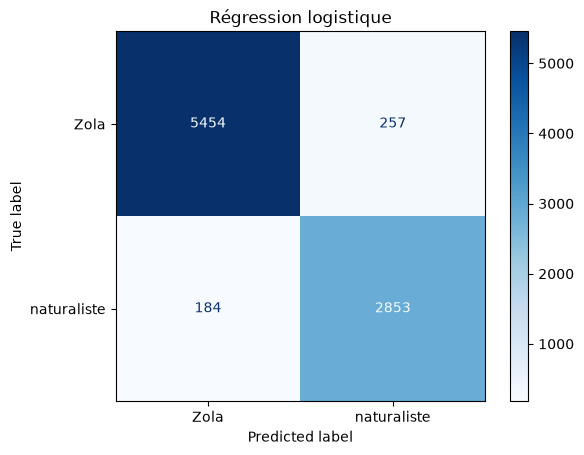

In [19]:
# Entraînement direct, sans Pipeline
modele_logistique = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

modele_logistique.fit(X_train_tfidf, y_train)

predictions_logistiques = modele_logistique.predict(X_test_tfidf)

print("=== Régression logistique ===")
print(classification_report(y_test, predictions_logistiques, digits=3))

cm_logistique = confusion_matrix(y_test, predictions_logistiques)
print("Matrice de confusion :")
print(cm_logistique)

ConfusionMatrixDisplay(
    confusion_matrix=cm_logistique,
    display_labels=modele_logistique.classes_
).plot(cmap="Blues")

plt.title("Régression logistique")
plt.show()


In [20]:
# Termes les plus discriminants de la régression logistique
termes_logistiques = vectorizer.get_feature_names_out()
classes_logistiques = modele_logistique.classes_

print("Ordre des classes :", classes_logistiques)

# En classification binaire :
# - coefficient positif  -> classe classes_[1]
# - coefficient négatif  -> classe classes_[0]
coefficients = modele_logistique.coef_[0]

importance_logistique = pd.DataFrame({
    "terme": termes_logistiques,
    "coefficient": coefficients
})

n = 30

termes_classe_0 = (
    importance_logistique
    .sort_values("coefficient", ascending=True)
    .head(n))

termes_classe_1 = (
    importance_logistique
    .sort_values("coefficient", ascending=False)
    .head(n))

print(f"\nTermes les plus associés à {classes_logistiques[0]} :")
for _, ligne in termes_classe_0.iterrows():
    print(f"{ligne['terme']:<30} {ligne['coefficient']:.4f}")

print(f"\nTermes les plus associés à {classes_logistiques[1]} :")
for _, ligne in termes_classe_1.iterrows():
    print(f"{ligne['terme']:<30} {ligne['coefficient']:.4f}")


Ordre des classes : ['Zola' 'naturaliste']

Termes les plus associés à Zola :
rougon                         -6.9898
saccard                        -5.8755
mouret                         -5.3281
qu                             -5.2905
lorsque                        -5.0545
était                          -4.6334
ça                             -4.6307
pauline                        -4.6149
ai                             -4.5354
abbé                           -4.5193
lorsqu                         -4.4613
claude                         -4.3690
gervaise                       -4.2678
octave                         -4.2456
maxime                         -4.0172
renée                          -3.9626
denise                         -3.8602
coupeau                        -3.8421
jean                           -3.5742
empereur                       -3.4996
plassans                       -3.4162
étienne                        -3.3620
lazare                         -3.2599
tout un                  

## 3. Analyse discriminante linéaire

L'analyse discriminante linéaire ne travaille pas directement sur une matrice TF-IDF creuse comportant plusieurs milliers de colonnes. On réduit donc d'abord la dimension avec `TruncatedSVD`, puis on standardise les composantes avant d'entraîner la LDA.


=== Analyse discriminante linéaire ===
Nombre de composantes SVD : 100
Variance expliquée cumulée par la SVD : 0.140
              precision    recall  f1-score   support

        Zola      0.935     0.956     0.945      5711
 naturaliste      0.914     0.874     0.894      3037

    accuracy                          0.928      8748
   macro avg      0.924     0.915     0.920      8748
weighted avg      0.928     0.928     0.927      8748

Matrice de confusion :
[[5462  249]
 [ 382 2655]]


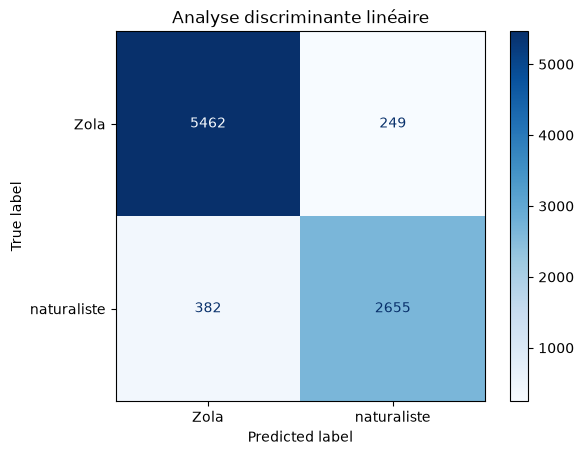

In [21]:
# Nombre de composantes compatible avec la taille réelle des données
n_composantes = min(
    100,
    X_train_tfidf.shape[0] - 1,
    X_train_tfidf.shape[1] - 1)

# Réduction de dimension
svd = TruncatedSVD(
    n_components=n_composantes,
    random_state=42)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

# Standardisation
scaler_lda = StandardScaler()
X_train_lda = scaler_lda.fit_transform(X_train_svd)
X_test_lda = scaler_lda.transform(X_test_svd)

# Analyse discriminante linéaire
modele_lda = LinearDiscriminantAnalysis(solver="svd")
modele_lda.fit(X_train_lda, y_train)

predictions_lda = modele_lda.predict(X_test_lda)

print("=== Analyse discriminante linéaire ===")
print(f"Nombre de composantes SVD : {n_composantes}")
print(
    "Variance expliquée cumulée par la SVD : "
    f"{svd.explained_variance_ratio_.sum():.3f}"
)
print(classification_report(y_test, predictions_lda, digits=3))

cm_lda = confusion_matrix(y_test, predictions_lda)
print("Matrice de confusion :")
print(cm_lda)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lda,
    display_labels=modele_lda.classes_
).plot(cmap="Blues")

plt.title("Analyse discriminante linéaire")
plt.show()


# Comparaison des modèles


In [22]:
comparaison_modeles = pd.DataFrame({
    "modèle": [
        "Analyse bayésienne",
        "Régression logistique",
        "Analyse discriminante linéaire"
    ],

    "accuracy": [
        accuracy_score(y_test, predictions),
        accuracy_score(y_test, predictions_logistiques),
        accuracy_score(y_test, predictions_lda)
    ],

    "f1_macro": [
        f1_score(y_test, predictions, average="macro"),
        f1_score(y_test, predictions_logistiques, average="macro"),
        f1_score(y_test, predictions_lda, average="macro")
    ]
})

comparaison_modeles.sort_values(
    "f1_macro",
    ascending=False
).reset_index(drop=True)


,modèle,accuracy,f1_macro
0,Régression logistique,0.949588,0.944700
1,Analyse discriminante linéaire,0.927869,0.919590
2,Analyse bayésienne,0.926726,0.919329
